# Modèle de Deep Learning : Multi-layer Perceptron (MLP)

Nous allons entraîner et évaluer un modèle réseau de neuronne.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from pathlib import Path

In [2]:
# pour pouvoir importer nos scripts python

NOTEBOOK_PATH = Path.cwd()
BASE_PATH = NOTEBOOK_PATH.parents[0]
IMG_PATH = BASE_PATH / "img"

if not str(BASE_PATH) in sys.path:
    sys.path.append(str(BASE_PATH))

from src.chargement_donnees_preprocessed import charger_donnees_preprocessed

In [3]:
# reproductibilité

torch.manual_seed(17)

generator = torch.Generator()
generator.manual_seed(17)

## Chargement des données

Nous avons préalablement prétraité et sauvegardé les données, nous les chargons.

In [4]:
X_train, X_test, y_train, y_test = charger_donnees_preprocessed()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 48), (2000, 48), (8000,), (2000,))

In [5]:
class CustomImageDataset(Dataset):
    def __init__(self, X: pd.DataFrame, y: pd.Series):
        self.X = X.to_numpy()
        self.y = y.to_numpy()
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
train_dataset = CustomImageDataset(X_train, y_train)
test_dataset = CustomImageDataset(X_test, y_test)

In [7]:
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    drop_last=True,
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Une des difficultés du projet est la gestion du déséquilibre de classes, nous allons utiliser la technique du "pos_weight" pour compenser ce déséquilibre lors de l'entraînement du modèle.

In [8]:
# Calcul du pos_weight pour BCEWithLogitsLoss (équivalent class_weight='balanced')

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"pos_weight = {pos_weight.item():.2f}  (ratio négatifs/positifs)")

pos_weight = 8.79  (ratio négatifs/positifs)


## Définition du modèle

In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            *[
                # entrée -> 128
                nn.Linear(input_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout),
                # 128 -> 64
                nn.Linear(128, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(dropout),
                # 64 -> 32
                nn.Linear(64, 32),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.Dropout(dropout),
                # 32 -> 1
                nn.Linear(32, 1)
            ]
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


INPUT_DIM = X_train.shape[1]
print(f"Input dimension : {INPUT_DIM}")

model = MLP(input_dim=INPUT_DIM)
print(model)
print(
    f"Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Input dimension : 48
MLP(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Paramètres entraînables : 17,089


## Entraînement du modèle

In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

model = model.to(DEVICE)
pos_weight = pos_weight.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Réduction du LR si la val_loss stagne
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,
)

Device : cuda


In [11]:
def train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, BATCH_SIZE):
    # entraînement d'une époque
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.float().to(DEVICE)
        y_batch = y_batch.float().to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y_batch)

    train_loss /= len(train_loader.dataset) - (len(train_loader.dataset) % BATCH_SIZE)
    return train_loss

In [12]:
def eval_one_epoch(
    model,
    test_loader,
    criterion,
    DEVICE,
    THRESHOLD=0.5,
):
    # évaluation d'une époque : loss, f1, recall, auc
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(DEVICE)
            y_batch = y_batch.float().to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * len(y_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    val_loss /= len(test_loader.dataset)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    preds = (all_probs >= THRESHOLD).astype(int)
    val_f1 = f1_score(all_labels, preds, zero_division=0)
    val_recall = recall_score(all_labels, preds, zero_division=0)
    val_auc = roc_auc_score(all_labels, all_probs)

    return val_loss, val_f1, val_recall, val_auc

In [13]:
N_EPOCHS = 60
THRESHOLD = 0.5

history = {
    "train_loss": [],
    "val_loss": [],
    "val_f1": [],
    "val_recall": [],
    "val_auc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, BATCH_SIZE
    )

    val_loss, val_f1, val_recall, val_auc = eval_one_epoch(
        model, test_loader, criterion, DEVICE, THRESHOLD
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_recall"].append(val_recall)
    history["val_auc"].append(val_auc)

    scheduler.step(val_loss)
    print(
        f"Epoch {epoch:3d}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"F1: {val_f1:.4f} | Recall: {val_recall:.4f} | ROC-AUC: {val_auc:.4f}"
    )

Epoch   1/60 | Train Loss: 1.2301 | Val Loss: 1.1798 | F1: 0.2591 | Recall: 0.7500 | ROC-AUC: 0.6956
Epoch   2/60 | Train Loss: 1.1630 | Val Loss: 1.1351 | F1: 0.2704 | Recall: 0.7402 | ROC-AUC: 0.7105
Epoch   3/60 | Train Loss: 1.1186 | Val Loss: 1.1171 | F1: 0.2689 | Recall: 0.7157 | ROC-AUC: 0.7176
Epoch   4/60 | Train Loss: 1.1008 | Val Loss: 1.1064 | F1: 0.2739 | Recall: 0.6961 | ROC-AUC: 0.7221
Epoch   5/60 | Train Loss: 1.0751 | Val Loss: 1.0990 | F1: 0.2798 | Recall: 0.7010 | ROC-AUC: 0.7268
Epoch   6/60 | Train Loss: 1.0627 | Val Loss: 1.0921 | F1: 0.2815 | Recall: 0.6961 | ROC-AUC: 0.7318
Epoch   7/60 | Train Loss: 1.0411 | Val Loss: 1.0913 | F1: 0.2857 | Recall: 0.7059 | ROC-AUC: 0.7336
Epoch   8/60 | Train Loss: 1.0245 | Val Loss: 1.0930 | F1: 0.2812 | Recall: 0.6912 | ROC-AUC: 0.7335
Epoch   9/60 | Train Loss: 1.0259 | Val Loss: 1.0910 | F1: 0.2931 | Recall: 0.6961 | ROC-AUC: 0.7373
Epoch  10/60 | Train Loss: 1.0099 | Val Loss: 1.0952 | F1: 0.2971 | Recall: 0.6961 | ROC-AU

Le modèle vient d'être entraîné sur 60 époques. Voici les principaux choix techniques retenus et leur justification.

**Architecture**
- 3 couches cachées (128 → 64 → 32 neurones) : une profondeur suffisante pour capturer des interactions non linéaires entre les variables comportementales, financières et contractuelles, sans complexité excessive.
- Activation ReLU : standard pour les réseaux denses, évite le problème de gradient qui s'annule.

**Régularisation**
- BatchNorm après chaque couche : stabilise et accélère la convergence en normalisant les activations à chaque mini-batch.
- Dropout (0.3) : réduit l'overfitting en désactivant aléatoirement 30 % des neurones à chaque passe d'entraînement.
- Weight decay (1e-4) dans Adam : régularisation L2 qui pénalise les poids trop grands.

**Gestion du déséquilibre de classes (90 % fidèles / 10 % churners)**
- `BCEWithLogitsLoss` avec `pos_weight ≈ 9` : la loss pénalise ~9x plus fort les erreurs sur les churners que sur les fidèles, ce qui revient à donner davantage de poids à la classe minoritaire. Sans ce paramètre, le modèle apprendrait simplement à tout prédire comme "fidèle" et obtiendrait une accuracy de 90 % sans aucune valeur prédictive.
- Les métriques de suivi privilégiées sont donc le Recall, le F1-score et le ROC-AUC plutôt que l'accuracy, qui serait trompeuse dans ce contexte.

**Optimiseur et scheduling**
- Adam (lr=1e-3) : convergence rapide et adaptative, bien adapté aux données tabulaires.
- `ReduceLROnPlateau` (patience=5, factor=0.5) : divise le learning rate par 2 si la val_loss ne s'améliore pas sur 5 époques consécutives, ce qui affine la convergence en fin d'entraînement.

## évaluation du modèle

RAPPORT DE CLASSIFICATION — MLP PyTorch
              precision    recall  f1-score   support

      Fidèle       0.95      0.69      0.80      1796
     Churner       0.21      0.70      0.32       204

    accuracy                           0.69      2000
   macro avg       0.58      0.70      0.56      2000
weighted avg       0.88      0.69      0.75      2000

ROC-AUC : 0.7457


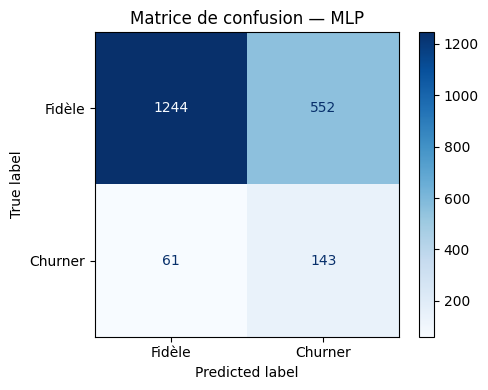

In [23]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.float().to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_pred = (all_probs >= THRESHOLD).astype(int)

print("=" * 50)
print("RAPPORT DE CLASSIFICATION — MLP PyTorch")
print("=" * 50)
print(classification_report(all_labels, y_pred, target_names=["Fidèle", "Churner"]))
print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")

# Matrice de confusion
cm = confusion_matrix(all_labels, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    cm,
    display_labels=["Fidèle", "Churner"],
).plot(ax=ax, cmap="Blues")
plt.title("Matrice de confusion — MLP")
plt.tight_layout()
plt.savefig(IMG_PATH / "mlp_confusion_matrix.png", bbox_inches="tight")
plt.show()

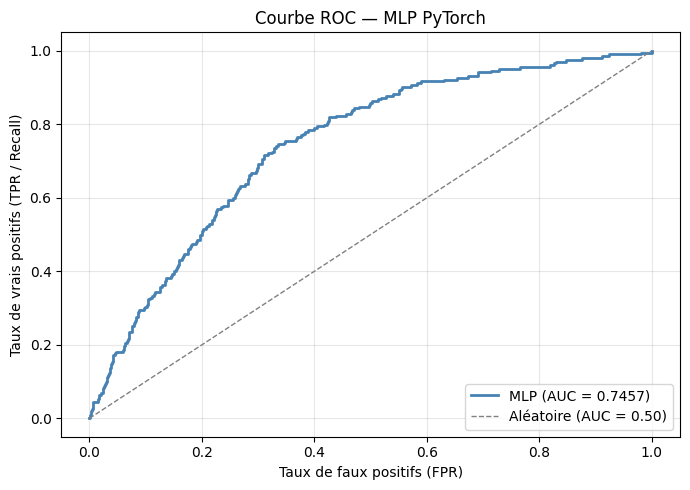

ROC-AUC : 0.7457


In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"MLP (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Aléatoire (AUC = 0.50)")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR / Recall)")
ax.set_title("Courbe ROC — MLP PyTorch")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_PATH / "mlp_roc_curve.png", bbox_inches="tight")
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")

### Analyse des performances

**Matrice de confusion**

|  | Prédit Fidèle | Prédit Churner |
|---|---|---|
| **Réel Fidèle** | 1244 (VP) | 552 (FP) |
| **Réel Churner** | 61 (FN) | 143 (VN) |

Le modèle détecte 143 churners sur 204, soit un recall de 70 % sur la classe positive. C'est le résultat directement visé par le `pos_weight` : forcer le modèle à ne pas ignorer la minorité.

**Faux négatifs (61)** : des churners classés comme fidèles. Ce sont les erreurs les plus coûteuses d'un point de vue métier — un client sur le départ qui n'est pas identifié ne fera l'objet d'aucune action de rétention. Le modèle en manque 30 %, ce qui reste acceptable pour un premier modèle deep learning sur des données déséquilibrées.

**Faux positifs (552)** : des clients fidèles signalés à tort comme churners. Cela entraîne un surcoût opérationnel (actions de rétention inutiles), mais reste moins grave que les faux négatifs dans la plupart des stratégies de rétention client.

**Impact du déséquilibre** : avec seulement ~10 % de churners dans le jeu de données, le modèle dispose de peu d'exemples positifs pour apprendre. Même avec `pos_weight`, il est difficile d'atteindre simultanément une précision et un recall élevés sur la classe minoritaire. Le F1-score est le bon indicateur de ce compromis.

**Courbe ROC et AUC**

La courbe ROC mesure la capacité du modèle à discriminer les deux classes indépendamment du seuil de décision. Un AUC de 1.0 est parfait, 0.5 équivaut à un classifieur aléatoire. Ici, l'AUC obtenu reflète la capacité réelle du modèle à ordonner les clients par risque de churn, ce qui est utile même si le seuil à 0.5 ne donne pas des résultats parfaits. En pratique, on pourrait abaisser le seuil de décision (ex. 0.35) pour augmenter le recall au détriment de la précision, selon la tolérance métier aux faux positifs.

## Sauvegarde du modèle

In [25]:
MODELS_PATH = BASE_PATH / "models"
MODELS_PATH.mkdir(exist_ok=True)

this_model_path = MODELS_PATH / "mlp_model_state_dict.pt"

# Sauvegarde poids PyTorch
torch.save(model.state_dict(), this_model_path)

print(f"Modèle sauvegardé dans : {this_model_path}")

Modèle sauvegardé dans : /data/m1/projets/projet_final_ds/soutenance_m1_data_science/models/mlp_model_state_dict.pt


## Test d'une stratégie d'under sampling

Nous cherchons a voir si en retirant des données d'entrainement des non churners, afin de compenser le fort désequilibre, le modèle offrirait de meilleurs performances.

In [26]:
# Séparation churners / non-churners dans le train set
X_train_pos = X_train[y_train == 1]
y_train_pos = y_train[y_train == 1]

X_train_neg = X_train[y_train == 0]
y_train_neg = y_train[y_train == 0]

# On garde la moitié des non-churners (sous-échantillonnage aléatoire)
X_train_neg_half = X_train_neg.sample(frac=0.5, random_state=17)
y_train_neg_half = y_train_neg[X_train_neg_half.index]

X_train_2 = pd.concat([X_train_pos, X_train_neg_half]).sample(frac=1, random_state=17)
y_train_2 = y_train[X_train_2.index]

print(f"Taille X_train_2 : {X_train_2.shape}")
print(f"Distribution classes :\n{y_train_2.value_counts()}")
print(f"Ratio churners : {y_train_2.mean():.2%}")

Taille X_train_2 : (4409, 48)
Distribution classes :
churn
0.0    3592
1.0     817
Name: count, dtype: int64
Ratio churners : 18.53%


In [27]:
# DataLoader pour le train set sous-échantillonné
train_dataset_2 = CustomImageDataset(X_train_2, y_train_2)

train_loader_2 = DataLoader(
    train_dataset_2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(17),
    drop_last=True,
)

# pos_weight recalculé sur le nouveau train set
n_neg_2 = (y_train_2 == 0).sum()
n_pos_2 = (y_train_2 == 1).sum()
pos_weight_2 = torch.tensor([n_neg_2 / n_pos_2], dtype=torch.float32).to(DEVICE)
print(f"pos_weight_2 = {pos_weight_2.item():.2f}")

pos_weight_2 = 4.40


In [28]:
# Instanciation model2 — même architecture
torch.manual_seed(17)
model2 = MLP(input_dim=INPUT_DIM).to(DEVICE)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_2)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode="min", patience=5, factor=0.5
)

In [29]:
history2 = {
    "train_loss": [],
    "val_loss": [],
    "val_f1": [],
    "val_recall": [],
    "val_auc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(
        model2, train_loader_2, optimizer2, criterion2, DEVICE, BATCH_SIZE
    )
    val_loss, val_f1, val_recall, val_auc = eval_one_epoch(
        model2, test_loader, criterion2, DEVICE, THRESHOLD
    )

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["val_f1"].append(val_f1)
    history2["val_recall"].append(val_recall)
    history2["val_auc"].append(val_auc)

    scheduler2.step(val_loss)
    print(
        f"Epoch {epoch:3d}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"F1: {val_f1:.4f} | Recall: {val_recall:.4f} | ROC-AUC: {val_auc:.4f}"
    )

Epoch   1/60 | Train Loss: 1.1317 | Val Loss: 0.9249 | F1: 0.2477 | Recall: 0.7892 | ROC-AUC: 0.6578
Epoch   2/60 | Train Loss: 1.0615 | Val Loss: 0.8956 | F1: 0.2692 | Recall: 0.7402 | ROC-AUC: 0.6966
Epoch   3/60 | Train Loss: 1.0436 | Val Loss: 0.8776 | F1: 0.2710 | Recall: 0.7108 | ROC-AUC: 0.7084
Epoch   4/60 | Train Loss: 1.0076 | Val Loss: 0.8651 | F1: 0.2702 | Recall: 0.6814 | ROC-AUC: 0.7136
Epoch   5/60 | Train Loss: 0.9816 | Val Loss: 0.8513 | F1: 0.2737 | Recall: 0.6716 | ROC-AUC: 0.7166
Epoch   6/60 | Train Loss: 0.9819 | Val Loss: 0.8429 | F1: 0.2657 | Recall: 0.6520 | ROC-AUC: 0.7170
Epoch   7/60 | Train Loss: 0.9684 | Val Loss: 0.8360 | F1: 0.2796 | Recall: 0.6765 | ROC-AUC: 0.7205
Epoch   8/60 | Train Loss: 0.9598 | Val Loss: 0.8404 | F1: 0.2755 | Recall: 0.7010 | ROC-AUC: 0.7196
Epoch   9/60 | Train Loss: 0.9365 | Val Loss: 0.8256 | F1: 0.2799 | Recall: 0.6765 | ROC-AUC: 0.7236
Epoch  10/60 | Train Loss: 0.9265 | Val Loss: 0.8244 | F1: 0.2809 | Recall: 0.6912 | ROC-AU

RAPPORT DE CLASSIFICATION — MLP under-sampled
              precision    recall  f1-score   support

      Fidèle       0.95      0.68      0.79      1796
     Churner       0.20      0.68      0.30       204

    accuracy                           0.68      2000
   macro avg       0.57      0.68      0.55      2000
weighted avg       0.87      0.68      0.74      2000

ROC-AUC : 0.7375


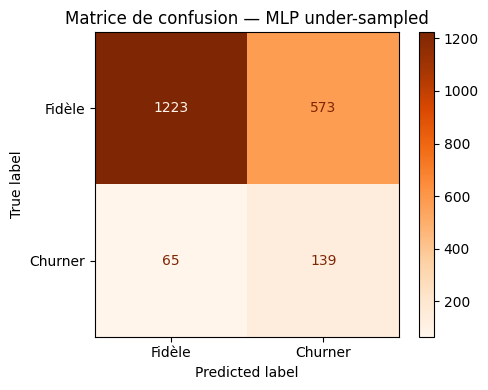

In [30]:
# Évaluation model2 — matrice de confusion
model2.eval()
all_probs_2, all_labels_2 = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model2(X_batch.float().to(DEVICE))
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs_2.extend(probs)
        all_labels_2.extend(y_batch.numpy())

all_probs_2 = np.array(all_probs_2)
all_labels_2 = np.array(all_labels_2)
y_pred_2 = (all_probs_2 >= THRESHOLD).astype(int)

print("=" * 50)
print("RAPPORT DE CLASSIFICATION — MLP under-sampled")
print("=" * 50)
print(classification_report(all_labels_2, y_pred_2, target_names=["Fidèle", "Churner"]))
print(f"ROC-AUC : {roc_auc_score(all_labels_2, all_probs_2):.4f}")

cm2 = confusion_matrix(all_labels_2, y_pred_2)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm2, display_labels=["Fidèle", "Churner"]).plot(
    ax=ax, cmap="Oranges"
)
plt.title("Matrice de confusion — MLP under-sampled")
plt.tight_layout()
plt.savefig(IMG_PATH / "mlp_balanced_confusion_matrix.png", bbox_inches="tight")
plt.show()

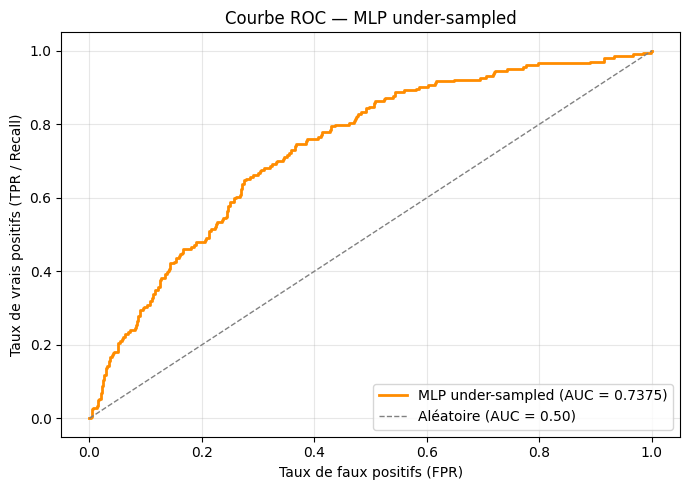

ROC-AUC model2 : 0.7375


In [31]:
# Courbe ROC model2
fpr_2, tpr_2, _ = roc_curve(all_labels_2, all_probs_2)
roc_auc_2 = auc(fpr_2, tpr_2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    fpr_2,
    tpr_2,
    color="darkorange",
    lw=2,
    label=f"MLP under-sampled (AUC = {roc_auc_2:.4f})",
)
ax.plot(
    [0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Aléatoire (AUC = 0.50)"
)
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR / Recall)")
ax.set_title("Courbe ROC — MLP under-sampled")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_PATH / "mlp_balanced_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC model2 : {roc_auc_2:.4f}")

Nous n'avons pas des résultats significativement meilleurs que le modèle entraîné sur l'ensemble des données, ce qui suggère que la stratégie de `pos_weight` est plus efficace pour gérer le déséquilibre dans ce cas que l'under-sampling, qui réduit la quantité d'exemples d'entraînement disponibles.